# Deterministic quality window by SVC

In [ ]:
import sys
import os
import pickle

import numpy as np
from scipy.spatial import Delaunay
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, to_rgba

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

## Load data and model

In [ ]:
import scripts.kernels as kernels
import sys

sys.modules["kernels"] = kernels  # pickle needs this to find AnisotropicMatern52

Xtrue = pd.read_csv("../_temp/X.csv").drop(columns="Slurry")
Window = np.load("../_temp/window.npy")

with open("../_temp/QW.SVC.pkl", "rb") as f:
    model = pickle.load(f)

### Construct prediction points

In [ ]:
g_vals = np.linspace(
    Xtrue["Gap_to_thickness_ratio"].min(),
    Xtrue["Gap_to_thickness_ratio"].max(),
    200,
)
ca_vals = np.linspace(
    Xtrue["Capillary_number"].min(),
    Xtrue["Capillary_number"].max(),
    200,
)
cos_vals = np.sort(Xtrue["Cos_theta"].unique())

Xpred = np.stack(np.meshgrid(g_vals, ca_vals, cos_vals, indexing="ij"), axis=-1)

### Find Delaunay regions

In [ ]:
N = Xpred.shape[-2]

simplices = []
for i in range(N):
    xtrue = Xtrue[Xtrue["Cos_theta"] == cos_vals[i]].values[:, :2]
    delaunay = Delaunay(xtrue.reshape(-1, 2))
    xpred = Xpred[:, :, i, :2]
    simplex = delaunay.find_simplex(xpred.reshape(-1, 2)) != -1
    simplices.append(simplex.reshape(Xpred.shape[:2]))
Delaunay = np.stack(simplices, axis=-1)

## Plot

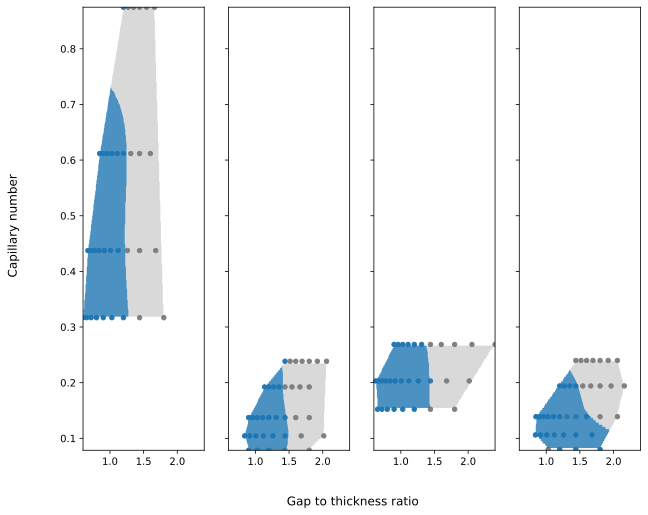

In [ ]:
fig = plt.figure(figsize=(10, 8))

if N == 1:
    axes = [fig.subplots(1, N, sharex=True, sharey=True)]
else:
    axes = fig.subplots(1, N, sharex=True, sharey=True).flatten()

decision_cmap = ListedColormap(
    [to_rgba("gray", alpha=0.3), to_rgba("tab:blue", alpha=0.8)]
)
decision_cmap.set_bad((0.0, 0.0, 0.0, 0.0))
decision_norm = BoundaryNorm([-0.5, 0.5, 1.5], decision_cmap.N)

for i, ax in enumerate(axes):

    df = Xtrue[Xtrue["Cos_theta"] == cos_vals[i]]
    x = df.drop(columns=["Cos_theta"]).values
    y = Window[df.index]
    colors = np.where(y.astype(bool), "tab:blue", "gray")
    scatter = ax.scatter(*x.T, c=colors, s=20)

    xpred = Xpred[:, :, i]
    delaunay = Delaunay[:, :, i]
    C = np.full_like(delaunay, np.nan, dtype=float)
    window = model.predict(xpred.reshape(-1, 3)).reshape(xpred.shape[:-1])
    C[delaunay] = window[delaunay]
    ax.contourf(
        xpred[..., 0],
        xpred[..., 1],
        np.ma.masked_invalid(C),
        levels=[-0.5, 0.5, 1.5],
        cmap=decision_cmap,
    )

fig.supxlabel("Gap to thickness ratio")
fig.supylabel("Capillary number")
plt.show()